In [6]:
pip install xarray netCDF4


[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import xarray as xr

file_path = "sample_netcdf_data.nc"
ds = xr.open_dataset(file_path)
print(ds)

<xarray.Dataset> Size: 44kB
Dimensions:        (PRES: 320)
Coordinates:
  * PRES           (PRES) float32 1kB 1.0 2.0 3.0 4.0 ... 318.0 319.0 320.0
Data variables: (12/33)
    PRES_QC        (PRES) float32 1kB ...
    TEMP           (PRES) float32 1kB ...
    PSAL           (PRES) float32 1kB ...
    FLU2           (PRES) float32 1kB ...
    CNDC           (PRES) float32 1kB ...
    DENS           (PRES) float32 1kB ...
    ...             ...
    OXYOCPVL-1_QC  (PRES) float32 1kB ...
    SPAR_QC        (PRES) float32 1kB ...
    PAR_QC         (PRES) float32 1kB ...
    PSAL-2_QC      (PRES) float32 1kB ...
    TEMP-2_QC      (PRES) float32 1kB ...
    ATTNZS01_QC    (PRES) float32 1kB ...
Attributes: (12/72)
    qc_manual:                       Recommendations for in-situ data Near Re...
    contact:                         datahjelp@hi.no
    distribution_statement:          These data are public and free of charge...
    naming_authority:                no.unis
    license:        

In [8]:
print(ds.variables)
print(ds.attrs)
print(ds["TEMP"].head())

Frozen({'PRES_QC': <xarray.Variable (PRES: 320)> Size: 1kB
[320 values with dtype=float32]
Attributes:
    conventions:    Copernicus Marine In Situ reference table 2
    valid_min:      0
    valid_max:      9
    flag_values:    [0 1 2 3 4 5 6 7 8 9]
    flag_meanings:  no_qc_performed good_data probably_good_data bad_data_tha...
    long_name:      Sea pressure quality flag, 'TEMP': <xarray.Variable (PRES: 320)> Size: 1kB
[320 values with dtype=float32]
Attributes:
    standard_name:          sea_water_temperature
    long_name:              Sea temperature
    units:                  degrees_C
    valid_min:              -2.5
    valid_max:              40.0
    ancillary_variables:    TEMP_QC 
    data_mode:              D
    coverage_content_type:  physicalMeasurement, 'PSAL': <xarray.Variable (PRES: 320)> Size: 1kB
[320 values with dtype=float32]
Attributes:
    standard_name:          sea_water_practical_salinity
    long_name:              Practical salinity
    units:       

In [9]:
temp = ds["TEMP"].values
print(temp)

psal = ds["PSAL"].values

[3.735 3.738 3.739 3.741 3.736 3.737 3.736 3.742 3.736 3.738 3.783 3.833
 3.838 3.837 3.83  3.806 3.792 3.79  3.814 3.846 3.858 3.833 3.815 3.817
 3.814 3.812 3.792 3.709 3.704 3.642 3.582 3.546 3.512 3.484 3.368 3.297
 3.165 3.106 3.094 3.094 3.102 3.079 3.094 3.076 3.035 3.009 2.992 2.981
 2.954 2.933 2.903 2.874 2.85  2.824 2.801 2.787 2.764 2.713 2.711 2.705
 2.701 2.696 2.682 2.665 2.651 2.647 2.642 2.635 2.624 2.588 2.604 2.608
 2.593 2.507 2.472 2.468 2.46  2.453 2.441 2.43  2.431 2.43  2.431 2.433
 2.43  2.417 2.394 2.382 2.361 2.335 2.32  2.303 2.275 2.267 2.263 2.277
 2.27  2.265 2.262 2.256 2.241 2.216 2.201 2.191 2.176 2.135 2.11  2.091
 2.071 2.064 2.103 2.106 2.099 2.095 2.092 2.088 2.082 2.085 2.093 2.09
 2.089 2.085 2.054 2.022 2.019 2.021 2.026 2.027 2.036 2.041 2.06  2.082
 2.084 2.087 2.093 2.097 2.099 2.098 2.1   2.101 2.099 2.095 2.094 2.094
 2.102 2.101 2.095 2.082 2.078 2.076 2.076 2.072 2.066 2.064 2.063 2.065
 2.065 2.063 2.058 2.041 2.032 2.028 2.027 2.026 2.0

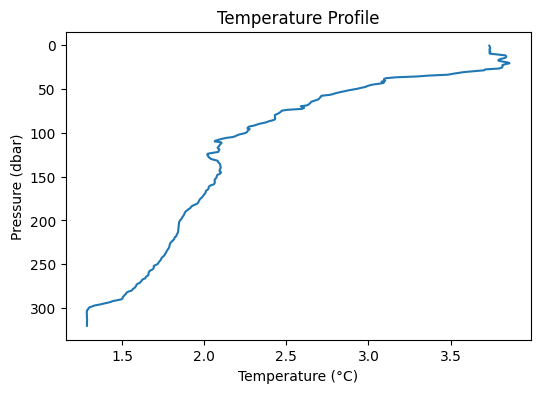

In [10]:
import matplotlib.pyplot as plt

pres = ds["PRES"].values
temp = ds["TEMP"].values

plt.figure(figsize=(6,4))
plt.plot(temp, pres)
plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (dbar)")
plt.title("Temperature Profile")
plt.show()


In [14]:
import xarray as xr
import pandas as pd

ds = xr.open_dataset("sample_netcdf_data.nc")

depth = ds['PRES'].values
temperature = ds['TEMP'].values
salinity = ds['PSAL'].values

lat = ds.attrs.get('latitude', None) or ds.attrs.get('geospatial_lat_min', None)
lon = ds.attrs.get('longitude', None) or ds.attrs.get('geospatial_lon_min', None)
date = ds.attrs.get('date_created', None)

df = pd.DataFrame({
    'depth': depth,
    'temperature': temperature,
    'salinity': salinity,
    'latitude': lat,
    'longitude': lon,
    'date': date
})

df.to_csv("argo_profiles.csv", index=False)
print(f"Saved argo_profiles.csv with {len(df)} rows")

Saved argo_profiles.csv with 320 rows
